## Model Analysis

* Results used in this notebook are derived from the baseline GRU model training.
* The code for this can be found in src/notebooks/test_eda1.py and src/notebooks/test_eda2.py

#### Imports and project root setup

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

#### Load the cached sequences

In [ ]:
landmark_dir = PROJECT_ROOT / "data" / "processed" / "landmarks"

with open(landmark_dir / "train_sequences.pkl", "rb") as file:
    train_sequences = pickle.load(file)

with open(landmark_dir / "validation_sequences.pkl", "rb") as file:
    validation_sequences = pickle.load(file)

print("Training sequences:", len(train_sequences))
print("Validation sequences:", len(validation_sequences))

Training sequences: 2484
Validation sequences: 633


#### Loading the class names

In [ ]:
from src.data.dataset import get_dataset_paths

paths = get_dataset_paths()

class_details = pd.read_csv(
    paths.class_details,
    sep="\t",
    skipinitialspace=True,
)

class_names = class_details["Label"].tolist()

print(class_names)

['D0X', 'B0A', 'B0B', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11']


#### 1. Create the Baseline results table

In [ ]:
baseline_results = pd.DataFrame({
    "strategy": [
        "fixed_192",
        "fixed_256",
        "hybrid",
    ],
    "best_val_accuracy": [
        0.7472,
        0.7441,
        0.7520,
    ],
    "training_time_min": [
        29.20,
        92.81,
        14.97,
    ],
})

baseline_results

,strategy,best_val_accuracy,training_time_min
0,fixed_192,0.7472,29.20
1,fixed_256,0.7441,92.81
2,hybrid,0.7520,14.97


#### 1.1 Plot the comparison of strategies

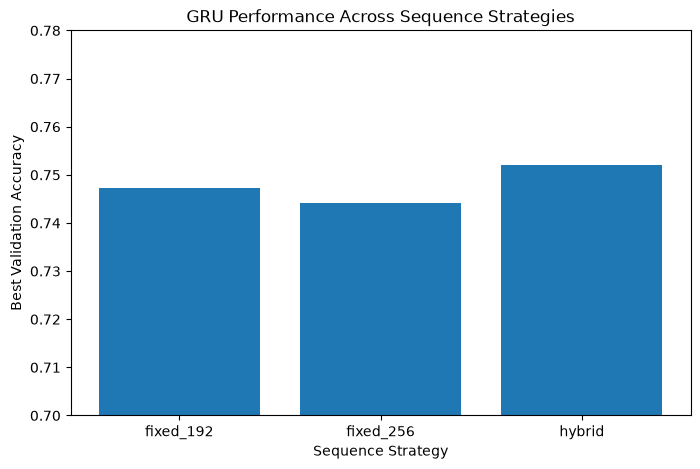

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results["strategy"],
    baseline_results["best_val_accuracy"],
)

plt.ylabel("Best Validation Accuracy")
plt.xlabel("Sequence Strategy")
plt.title("GRU Performance Across Sequence Strategies")
plt.ylim(0.70, 0.78)

plt.show()

#### 2. Class-wise performance

In [ ]:
gesture_class_names = class_names[1:]

print(gesture_class_names)

['B0A', 'B0B', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11']


In [ ]:
class_performance = pd.DataFrame({
    "class": gesture_class_names,
    "precision": [
        1.000, 0.925, 0.442, 0.143, 0.714, 0.893,
        0.900, 0.917, 0.541, 0.227, 0.375, 0.378, 0.714
    ],
    "recall": [
        0.941, 0.987, 0.633, 0.033, 0.333, 0.833,
        0.900, 0.733, 0.667, 0.167, 0.900, 0.567, 0.167
    ],
    "f1": [
        0.969, 0.955, 0.521, 0.054, 0.455, 0.862,
        0.900, 0.815, 0.597, 0.192, 0.529, 0.453, 0.270
    ],
})

class_performance

,class,precision,recall,f1
0,B0A,1.000,0.941,0.969
1,B0B,0.925,0.987,0.955
2,G01,0.442,0.633,0.521
3,G02,0.143,0.033,0.054
4,G03,0.714,0.333,0.455
5,G04,0.893,0.833,0.862
6,G05,0.900,0.900,0.900
7,G06,0.917,0.733,0.815
8,G07,0.541,0.667,0.597
9,G08,0.227,0.167,0.192


#### 2.1 Visualization

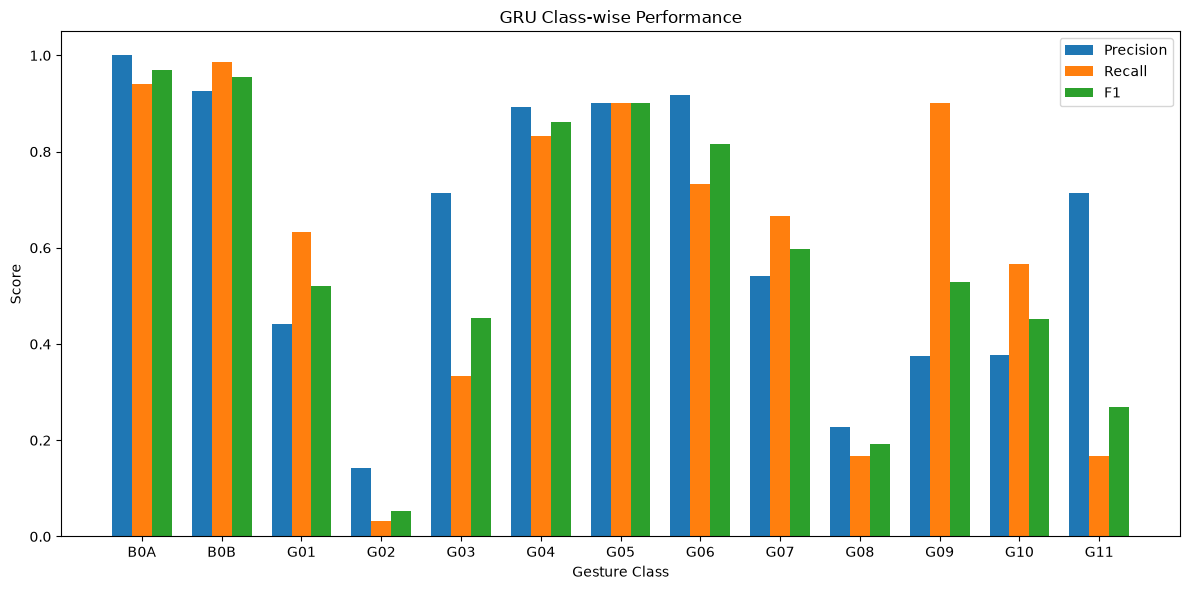

In [ ]:
plt.figure(figsize=(12, 6))

x = np.arange(len(class_performance))
width = 0.25

plt.bar(
    x - width,
    class_performance["precision"],
    width,
    label="Precision",
)

plt.bar(
    x,
    class_performance["recall"],
    width,
    label="Recall",
)

plt.bar(
    x + width,
    class_performance["f1"],
    width,
    label="F1",
)

plt.xticks(x, class_performance["class"])
plt.ylabel("Score")
plt.xlabel("Gesture Class")
plt.title("GRU Class-wise Performance")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

#### 2.3 Confusion Matrix

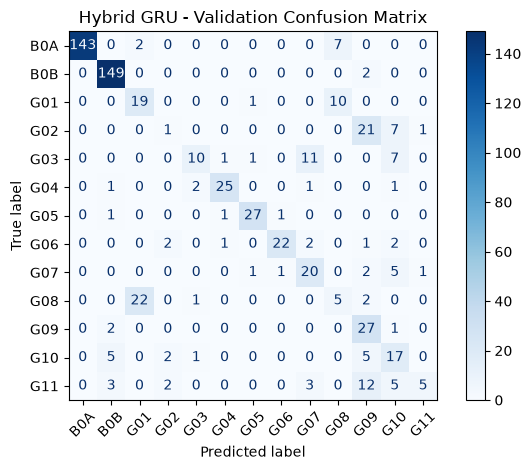

In [ ]:
confusion_matrix_values = np.array([
    [143, 0, 2, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0],
    [0, 149, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
    [0, 0, 19, 0, 0, 0, 1, 0, 0, 10, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 21, 7, 1],
    [0, 0, 0, 0, 10, 1, 1, 0, 11, 0, 0, 7, 0],
    [0, 1, 0, 0, 2, 25, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 27, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 2, 0, 1, 0, 22, 2, 0, 1, 2, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 20, 0, 2, 5, 1],
    [0, 0, 22, 0, 1, 0, 0, 0, 0, 5, 2, 0, 0],
    [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 27, 1, 0],
    [0, 5, 0, 2, 1, 0, 0, 0, 0, 0, 5, 17, 0],
    [0, 3, 0, 2, 0, 0, 0, 0, 3, 0, 12, 5, 5],
])

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=gesture_class_names,
).plot(
    xticks_rotation=45,
    values_format="d",
    cmap="Blues",
)

plt.title("Hybrid GRU - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

#### 2.4 Training F1 Scores

In [ ]:
training_f1 = [
    0.969, 0.955, 0.547, 0.127, 0.429, 0.847,
    0.898, 0.815, 0.585, 0.406, 0.531, 0.536, 0.308
]

comparison = pd.DataFrame({
    "class": gesture_class_names,
    "train_f1": training_f1,
    "validation_f1": class_performance["f1"],
})

comparison["f1_gap"] = (
    comparison["train_f1"] - comparison["validation_f1"]
)

comparison

,class,train_f1,validation_f1,f1_gap
0,B0A,0.969,0.969,0.000
1,B0B,0.955,0.955,0.000
2,G01,0.547,0.521,0.026
3,G02,0.127,0.054,0.073
4,G03,0.429,0.455,-0.026
5,G04,0.847,0.862,-0.015
6,G05,0.898,0.900,-0.002
7,G06,0.815,0.815,0.000
8,G07,0.585,0.597,-0.012
9,G08,0.406,0.192,0.214


#### 2.5 Detection rate across classes

In [ ]:
detection_by_class = pd.DataFrame({
    "class": gesture_class_names,
    "detection_rate": [
        0.911827,
        0.884485,
        0.938418,
        0.910814,
        0.949992,
        0.895579,
        0.940390,
        0.935563,
        0.960919,
        0.931885,
        0.918307,
        0.941344,
        0.966661,
    ],
})

class_diagnostics = class_performance.merge(
    detection_by_class,
    on="class",
)

class_diagnostics

,class,precision,recall,f1,detection_rate
0,B0A,1.000,0.941,0.969,0.911827
1,B0B,0.925,0.987,0.955,0.884485
2,G01,0.442,0.633,0.521,0.938418
3,G02,0.143,0.033,0.054,0.910814
4,G03,0.714,0.333,0.455,0.949992
5,G04,0.893,0.833,0.862,0.895579
6,G05,0.900,0.900,0.900,0.940390
7,G06,0.917,0.733,0.815,0.935563
8,G07,0.541,0.667,0.597,0.960919
9,G08,0.227,0.167,0.192,0.931885


#### 2.5.1 Visualization of detection rate

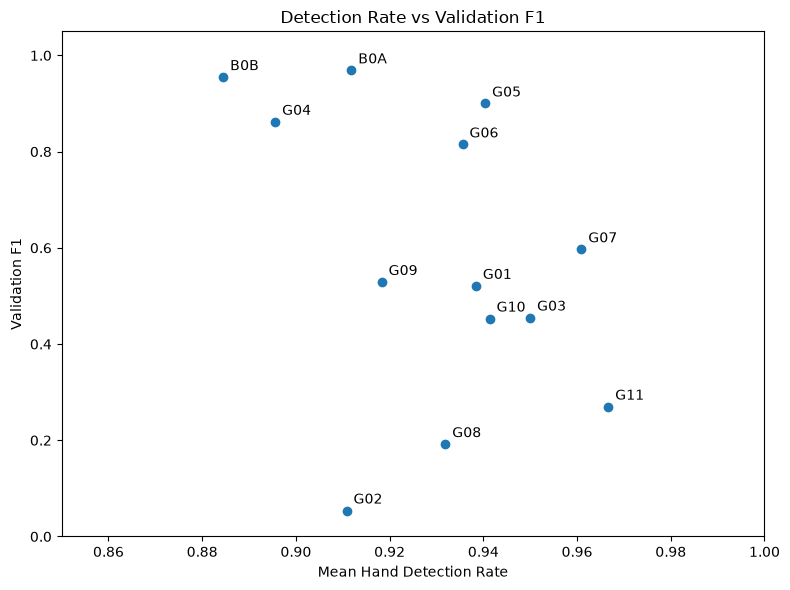

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    class_diagnostics["detection_rate"],
    class_diagnostics["f1"],
)

for _, row in class_diagnostics.iterrows():
    plt.annotate(
        row["class"],
        (row["detection_rate"], row["f1"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Mean Hand Detection Rate")
plt.ylabel("Validation F1")
plt.title("Detection Rate vs Validation F1")
plt.xlim(0.85, 1.0)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Key Findings
1. Under the current GRU architecture and training configuration, the three temporal preprocessing strategies produced similar validation accuracy, while their training times differed substantially.

## Experiment 2: Add explicit motion features

#### 63 position features -> 126 features (63 position and 63 motion)
* we add the motion features by calculating change in x.
* Change = position x(t) - position x(t-1)

#### 1. Calculate motion

In [ ]:
def add_motion_features(sequence):
    """
    Add frame-to-frame landmark movement to position features.

    Input:
        sequence: (T, 63)

    Output:
        combined: (T, 126)
    """
    motion = np.zeros_like(sequence) ## for the first sequence we take (0,0,0)

    motion[1:] = sequence[1:] - sequence[:-1]

    combined = np.concatenate(
        [sequence, motion],
        axis=1,
    )

    return combined

#### 1.1 Test motion features on one sequence

In [ ]:
import numpy as np
sample_sequence = train_sequences[0].landmarks

print("Original shape:", sample_sequence.shape)

sample_with_motion = add_motion_features(sample_sequence)

print("New shape:", sample_with_motion.shape)

Original shape: (38, 63)
New shape: (38, 126)


In [ ]:
## first frame (expected: zeros)
print("First-frame motion:")
print(sample_with_motion[0, 63:])

## second frame
print("Second-frame motion:")
print(sample_with_motion[1, 63:])

First-frame motion:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Second-frame motion:
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -6.96623325e-03
  1.62541866e-03  1.18620694e-03 -1.37428045e-02  7.97420740e-03
 -3.94623727e-04 -1.40157044e-02  9.10103321e-03 -7.16663897e-04
 -2.65052915e-03 -6.66862726e-03 -1.99694186e-04 -1.66078806e-02
  1.12497807e-02 -4.45629470e-04 -1.19708180e-02  1.78351998e-02
  5.09321690e-05 -5.66968322e-03  1.44997239e-02  2.07662582e-04
 -1.52844191e-03  4.88072634e-03  1.04315579e-03 -1.51061118e-02
  8.15671682e-03  1.40783004e-03 -1.32652521e-02  9.13912058e-03
  2.06325948e-03 -8.72427225e-03  1.53541565e-02  4.63985652e-03
 -5.48774004e-03  2.05713809e-02  8.64698738e-03 -1.19580328e-02
  4.98080254e-03  4.07871790e-03 -5.03939390e-03  7.61321187e-03
  8.08652490e-03  1.89995766e-03  3.13901901e-03  1

#### 1.2 Apply transformation to train and validation sequences

In [ ]:
train_sequences_with_motion = [
    add_motion_features(sequence.landmarks)
    for sequence in train_sequences
]

validation_sequences_with_motion = [
    add_motion_features(sequence.landmarks)
    for sequence in validation_sequences
]

print("Training sequences:", len(train_sequences_with_motion))
print("Validation sequences:", len(validation_sequences_with_motion))

print(
    "Example training shape:",
    train_sequences_with_motion[0].shape,
)

print(
    "Example validation shape:",
    validation_sequences_with_motion[0].shape,
)

Training sequences: 2484
Validation sequences: 633
Example training shape: (38, 126)
Example validation shape: (123, 126)


#### Functions used by hybrid strategy

In [ ]:
def resample_sequence(sequence, target_length):
    """
    Resample a temporal sequence to a fixed number of frames.

    Input:
        sequence: (T, F)
        target_length: desired number of frames

    Output:
        resampled sequence: (target_length, F)
    """
    original_length = sequence.shape[0]

    if original_length == target_length:
        return sequence.copy()

    original_positions = np.linspace(
        0,
        original_length - 1,
        num=original_length,
    )

    target_positions = np.linspace(
        0,
        original_length - 1,
        num=target_length,
    )

    resampled = np.empty(
        (target_length, sequence.shape[1]),
        dtype=np.float32,
    )

    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            original_positions,
            sequence[:, feature_index],
        )

    return resampled

In [ ]:
SHORT_SEQUENCE_LIMIT = 192
LONG_SEQUENCE_LIMIT = 256


def prepare_sequence(sequence, strategy):
    """
    Apply a temporal preprocessing strategy to a sequence.
    """
    sequence_length = sequence.shape[0]

    if strategy == "fixed_192":
        return resample_sequence(
            sequence,
            SHORT_SEQUENCE_LIMIT,
        )

    if strategy == "fixed_256":
        return resample_sequence(
            sequence,
            LONG_SEQUENCE_LIMIT,
        )

    if strategy == "hybrid":
        if sequence_length < SHORT_SEQUENCE_LIMIT:
            target_length = sequence_length
        elif sequence_length <= LONG_SEQUENCE_LIMIT:
            target_length = SHORT_SEQUENCE_LIMIT
        else:
            target_length = LONG_SEQUENCE_LIMIT

        return resample_sequence(
            sequence,
            target_length,
        )

    raise ValueError(
        f"Unknown sequence strategy: {strategy}"
    )

In [ ]:
train_motion_hybrid = [
    prepare_sequence(sequence, "hybrid")
    for sequence in train_sequences_with_motion
]

validation_motion_hybrid = [
    prepare_sequence(sequence, "hybrid")
    for sequence in validation_sequences_with_motion
]

print("Training sequences:", len(train_motion_hybrid))
print("Validation sequences:", len(validation_motion_hybrid))

print("Example training shape:", train_motion_hybrid[0].shape)
print("Example validation shape:", validation_motion_hybrid[0].shape)

Training sequences: 2484
Validation sequences: 633
Example training shape: (38, 126)
Example validation shape: (123, 126)


In [ ]:
train_feature_sizes = {
    sequence.shape[1]
    for sequence in train_motion_hybrid
}

validation_feature_sizes = {
    sequence.shape[1]
    for sequence in validation_motion_hybrid
}

print("Training feature sizes:", train_feature_sizes)
print("Validation feature sizes:", validation_feature_sizes)

Training feature sizes: {126}
Validation feature sizes: {126}


#### 3. Build and implement the 126 input GRU

#### 3.1 Imports and configuration

In [ ]:
import torch
import torch.nn as nn

INPUT_SIZE = 126
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = 13
DROPOUT = 0.0

#### 3.2 GRU Model

In [ ]:
class GestureGRU(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        dropout=0.0,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Linear(
            hidden_size,num_classes
        )

    def forward(self,x,lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _,hidden = self.gru(packed)
        final_hidden = hidden[-1]
        return self.classifier(final_hidden)

In [ ]:
model = GestureGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
)

print(model)

GestureGRU(
  (gru): GRU(126, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=13, bias=True)
)


In [ ]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total parameters:", total_parameters)

Total parameters: 99981


#### 3.3 Convert numpy sequences into PyTorch tensors

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


class GestureDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = np.asarray(labels) - 2

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.float32,
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )

        return sequence, label

In [ ]:
def collate_sequences(batch):
    sequences, labels = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    lengths = torch.tensor(
        [sequence.shape[0] for sequence in sequences],
        dtype=torch.long,
    )

    labels = torch.stack(labels)

    return padded_sequences, lengths, labels

In [ ]:
## create the datasets
train_dataset = GestureDataset(
    train_motion_hybrid,
    [sequence.class_id for sequence in train_sequences],
)

validation_dataset = GestureDataset(
    validation_motion_hybrid,
    [sequence.class_id for sequence in validation_sequences],
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))

Training samples: 2484
Validation samples: 633


#### 3.4 Dataloaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 78
Validation batches: 20


#### 3.5 Test on one batch

In [ ]:
batch_sequences, batch_lengths, batch_labels = next(
    iter(train_loader)
)

print("Batch sequences:", batch_sequences.shape)
print("Batch lengths:", batch_lengths.shape)
print("Batch labels:", batch_labels.shape)

Batch sequences: torch.Size([32, 256, 126])
Batch lengths: torch.Size([32])
Batch labels: torch.Size([32])


## Colab Environment Configuration

In [ ]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


#### Cached landmark files into Colab runtime

In [ ]:
from pathlib import Path

drive_landmark_dir = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "landmarks"
)

print("Drive landmark folder exists:", drive_landmark_dir.exists())

for file in drive_landmark_dir.iterdir():
    print(file.name)

Drive landmark folder exists: True
train_sequences.pkl
validation_sequences.pkl


#### Temporarily clone the repo

In [ ]:
!git clone https://github.com/Smruti-R18/AirCommand /content/AirCommand

Cloning into '/content/AirCommand'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 31 (delta 5), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 4.38 MiB | 16.55 MiB/s, done.
Resolving deltas: 100% (5/5), done.


#### Verify the Project paths exist

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/content/AirCommand")

print("src:", (PROJECT_ROOT / "src").exists())
print("configs:", (PROJECT_ROOT / "configs").exists())
print("models:", (PROJECT_ROOT / "models").exists())

src: True
configs: True
models: False


#### Load the hand_landmarker.task file from drive

In [ ]:
from pathlib import Path
import shutil

drive_model = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "mediapipe"
    / "hand_landmarker.task"
)

project_model = (
    Path("/content/AirCommand")
    / "models"
    / "mediapipe"
    / "hand_landmarker.task"
)

project_model.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if not drive_model.exists():
    raise FileNotFoundError(
        f"MediaPipe model not found: {drive_model}"
    )

shutil.copy2(
    drive_model,
    project_model,
)

print("MediaPipe model:", project_model.exists())

MediaPipe model: True


#### Put the cached landmarks into project

In [ ]:
from pathlib import Path
import shutil

drive_landmark_dir = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "landmarks"
)

project_landmark_dir = (
    Path("/content/AirCommand")
    / "data"
    / "processed"
    / "landmarks"
)

project_landmark_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for filename in [
    "train_sequences.pkl",
    "validation_sequences.pkl",
]:
    shutil.copy2(
        drive_landmark_dir / filename,
        project_landmark_dir / filename,
    )

print("Landmark files copied.")

Landmark files copied.


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/AirCommand")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Import path configured.")

Project root: /content/AirCommand
Import path configured.


#### Configure environment variables expected by settings.py

In [ ]:
import os

os.environ["AIRCOMMAND_DATASET_ROOT"] = str(
    PROJECT_ROOT / "data" / "processed" / "landmarks"
)

print(
    "AIRCOMMAND_DATASET_ROOT:",
    os.environ["AIRCOMMAND_DATASET_ROOT"],
)

AIRCOMMAND_DATASET_ROOT: /content/AirCommand/data/processed/landmarks


In [ ]:
## test project import
from src.config.settings import PROJECT_ROOT as CONFIG_PROJECT_ROOT

print("Import successful.")
print("Configured project root:", CONFIG_PROJECT_ROOT)

Import successful.
Configured project root: /content/AirCommand


## Project variable configuration in colab

In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import pickle

landmark_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "landmarks"
)

with open(
    landmark_dir / "train_sequences.pkl",
    "rb",
) as file:
    train_sequences = pickle.load(file)

with open(
    landmark_dir / "validation_sequences.pkl",
    "rb",
) as file:
    validation_sequences = pickle.load(file)

print("Train sequences:", len(train_sequences))
print("Validation sequences:", len(validation_sequences))

Train sequences: 2484
Validation sequences: 633


In [ ]:
print("Example train sequence:")
print("Video:", train_sequences[0].video)
print("Label:", train_sequences[0].label)
print("Class ID:", train_sequences[0].class_id)
print("Shape:", train_sequences[0].landmarks.shape)
print("Dtype:", train_sequences[0].landmarks.dtype)

Example train sequence:
Video: 1CM1_4_R__229
Label: G11
Class ID: 14
Shape: (38, 63)
Dtype: float32


## Model Definition and Training

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")
print("Model device before moving:", next(model.parameters()).device)
print("Device:", device)
print("Model device:", next(model.parameters()).device)

Device: cuda
GPU: Tesla T4
Model device before moving: cpu
Device: cuda
Model device: cpu


In [ ]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


#### Training

In [ ]:
import time
import random
import numpy as np
import torch
import torch.nn as nn


# --------------------------------------------------
# 1. Reproducibility
# --------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# --------------------------------------------------
# 2. Training configuration
# --------------------------------------------------

LEARNING_RATE = 1e-3
EPOCHS = 15


# --------------------------------------------------
# 3. Loss function and optimizer
# --------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


# --------------------------------------------------
# 4. Variables for tracking training
# --------------------------------------------------

training_history = []

best_validation_accuracy = 0.0
best_epoch = 0
best_model_state = None


# --------------------------------------------------
# 5. Start training
# --------------------------------------------------

start_time = time.time()

for epoch in range(EPOCHS):

    # ==============================================
    # Training
    # ==============================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_sequences, batch_lengths, batch_labels in train_loader:

        # Move data to GPU
        batch_sequences = batch_sequences.to(device)
        batch_lengths = batch_lengths.to(device)
        batch_labels = batch_labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            batch_sequences,
            batch_lengths,
        )

        # Calculate loss
        loss = criterion(
            outputs,
            batch_labels,
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        running_loss += (
            loss.item() * batch_labels.size(0)
        )

        # Calculate predictions
        predictions = outputs.argmax(dim=1)

        # Count correct predictions
        correct += (
            predictions == batch_labels
        ).sum().item()

        total += batch_labels.size(0)

    # Calculate epoch-level training metrics
    train_loss = running_loss / total
    train_accuracy = correct / total


    # ==============================================
    # Validation
    # ==============================================

    model.eval()

    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():

        for batch_sequences, batch_lengths, batch_labels in validation_loader:

            # Move data to GPU
            batch_sequences = batch_sequences.to(device)
            batch_lengths = batch_lengths.to(device)
            batch_labels = batch_labels.to(device)

            # Forward pass
            outputs = model(
                batch_sequences,
                batch_lengths,
            )

            # Calculate validation loss
            loss = criterion(
                outputs,
                batch_labels,
            )

            validation_loss += (
                loss.item() * batch_labels.size(0)
            )

            # Calculate predictions
            predictions = outputs.argmax(dim=1)

            validation_correct += (
                predictions == batch_labels
            ).sum().item()

            validation_total += batch_labels.size(0)

    # Calculate epoch-level validation metrics
    validation_loss /= validation_total

    validation_accuracy = (
        validation_correct / validation_total
    )


    # ==============================================
    # Save training history
    # ==============================================

    training_history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        }
    )


    # ==============================================
    # Save best model
    # ==============================================

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }


    # ==============================================
    # Print epoch results
    # ==============================================

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy:.4f}"
    )


# --------------------------------------------------
# 6. Training time
# --------------------------------------------------

training_time = time.time() - start_time


# --------------------------------------------------
# 7. Restore best model
# --------------------------------------------------

model.load_state_dict(best_model_state)


# --------------------------------------------------
# 8. Final training summary
# --------------------------------------------------

print()
print(f"Best epoch: {best_epoch}")
print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy:.4f}"
)
print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

Epoch 01/15 | Train Loss: 0.5962 | Train Acc: 0.7943 | Val Loss: 0.6629 | Val Acc: 0.7599
Epoch 02/15 | Train Loss: 0.6252 | Train Acc: 0.7750 | Val Loss: 0.5305 | Val Acc: 0.8009
Epoch 03/15 | Train Loss: 0.5498 | Train Acc: 0.8076 | Val Loss: 0.5560 | Val Acc: 0.7852
Epoch 04/15 | Train Loss: 0.5434 | Train Acc: 0.8060 | Val Loss: 0.4585 | Val Acc: 0.8246
Epoch 05/15 | Train Loss: 0.5087 | Train Acc: 0.8168 | Val Loss: 0.5317 | Val Acc: 0.7946
Epoch 06/15 | Train Loss: 0.4960 | Train Acc: 0.8277 | Val Loss: 0.5794 | Val Acc: 0.8025
Epoch 07/15 | Train Loss: 0.4607 | Train Acc: 0.8289 | Val Loss: 0.3971 | Val Acc: 0.8468
Epoch 08/15 | Train Loss: 0.4301 | Train Acc: 0.8442 | Val Loss: 0.4965 | Val Acc: 0.8104
Epoch 09/15 | Train Loss: 0.4250 | Train Acc: 0.8426 | Val Loss: 0.4241 | Val Acc: 0.8310
Epoch 10/15 | Train Loss: 0.4066 | Train Acc: 0.8438 | Val Loss: 0.4189 | Val Acc: 0.8325
Epoch 11/15 | Train Loss: 0.4031 | Train Acc: 0.8498 | Val Loss: 0.3505 | Val Acc: 0.8578
Epoch 12/1

#### Compare and check the metrics

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import numpy as np
import torch


model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch_sequences, batch_lengths, batch_labels in validation_loader:

        batch_sequences = batch_sequences.to(device)
        batch_lengths = batch_lengths.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(
            batch_sequences,
            batch_lengths,
        )

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch_labels.cpu().numpy()
        )


all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

accuracy = accuracy_score(
    all_labels,
    all_predictions,
)

print(f"Validation accuracy: {accuracy:.4f}")

print("\nClassification report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        digits=3,
    )
)

Validation accuracy: 0.8736

Classification report:

              precision    recall  f1-score   support

           0      1.000     0.961     0.980       152
           1      0.993     0.993     0.993       151
           2      0.647     0.367     0.468        30
           3      0.533     0.267     0.356        30
           4      0.875     0.933     0.903        30
           5      0.967     0.967     0.967        30
           6      1.000     1.000     1.000        30
           7      0.966     0.933     0.949        30
           8      0.853     0.967     0.906        30
           9      0.489     0.767     0.597        30
          10      0.523     0.767     0.622        30
          11      0.955     0.700     0.808        30
          12      0.750     0.900     0.818        30

    accuracy                          0.874       633
   macro avg      0.812     0.809     0.797       633
weighted avg      0.883     0.874     0.870       633



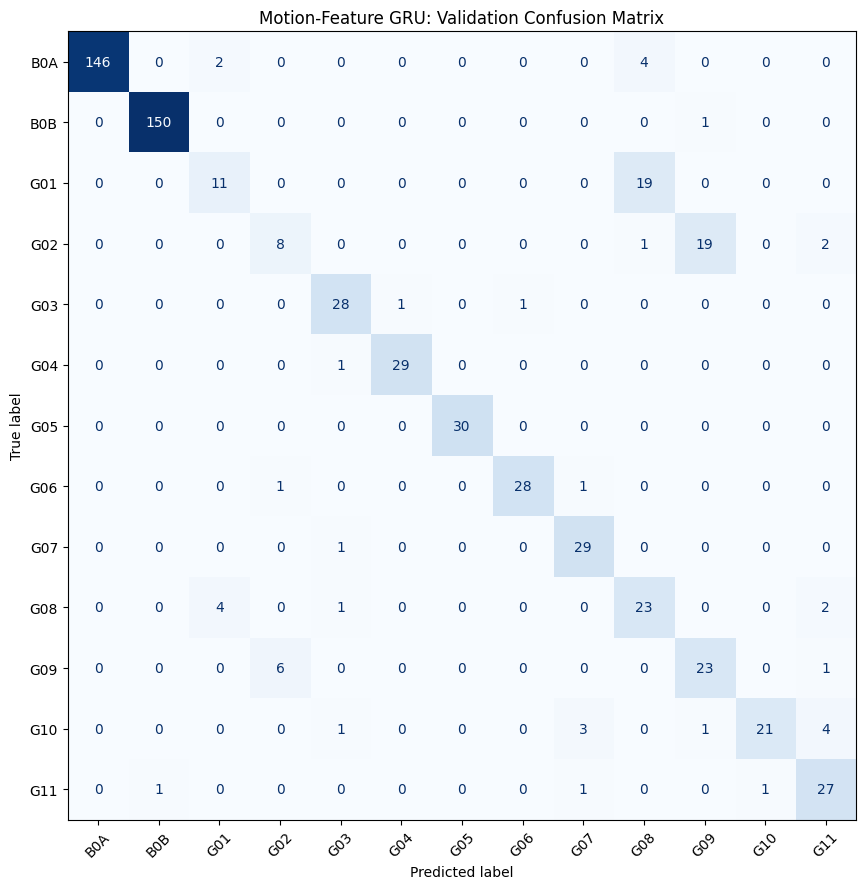

In [ ]:
## Confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "B0A",
    "B0B",
    "G01",
    "G02",
    "G03",
    "G04",
    "G05",
    "G06",
    "G07",
    "G08",
    "G09",
    "G10",
    "G11",
]

cm = confusion_matrix(
    all_labels,
    all_predictions,
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
).plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
)

ax.set_title(
    "Motion-Feature GRU: Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

***
saving the PyTorch checkpoint containing:

- model architecture information
- trained weights
- input size = 126
- hidden size = 128
- number of classes = 13
- best epoch = 15
- validation accuracy = 0.8736
- training configuration
***

In [ ]:
from pathlib import Path
import torch


checkpoint_dir = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

checkpoint_path = (
    checkpoint_dir
    / "motion_gru_best.pt"
)


checkpoint = {
    "model_state_dict": model.state_dict(),

    "model_config": {
        "input_size": 126,
        "hidden_size": 128,
        "num_layers": 1,
        "num_classes": 13,
        "dropout": 0.0,
    },

    "training_config": {
        "learning_rate": 1e-3,
        "epochs": 15,
        "batch_size": 32,
        "seed": 42,
        "sequence_strategy": "hybrid",
        "features": "position + first_order_motion",
    },

    "best_epoch": best_epoch,
    "best_validation_accuracy": best_validation_accuracy,
}

torch.save(
    checkpoint,
    checkpoint_path,
)

print("Checkpoint saved to:")
print(checkpoint_path)
print("Exists:", checkpoint_path.exists())

Checkpoint saved to:
/content/drive/MyDrive/AirCommand/checkpoints/motion_gru_best.pt
Exists: True


## Comparison with baseline model

#### 1. feature comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


comparison = pd.DataFrame(
    {
        "Experiment": [
            "Baseline GRU",
            "Position + Motion GRU",
        ],
        "Input Features": [
            63,
            126,
        ],
        "Parameters": [
            74112,
            99981,
        ],
        "Best Validation Accuracy": [
            0.7520,
            0.8736,
        ],
        "Macro F1": [
            0.583,
            0.797,
        ],
        "Weighted F1": [
            0.728,
            0.870,
        ],
        "Training Time (min)": [
            14.97,
            0.29,
        ],
    }
)

comparison

,Experiment,Input Features,Parameters,Best Validation Accuracy,Macro F1,Weighted F1,Training Time (min)
0,Baseline GRU,63,74112,0.7520,0.583,0.728,14.97
1,Position + Motion GRU,126,99981,0.8736,0.797,0.870,0.29


#### 2. Improvement

In [ ]:
accuracy_improvement = (
    comparison.loc[1, "Best Validation Accuracy"]
    - comparison.loc[0, "Best Validation Accuracy"]
)

macro_f1_improvement = (
    comparison.loc[1, "Macro F1"]
    - comparison.loc[0, "Macro F1"]
)

print(
    f"Validation accuracy improvement: "
    f"{accuracy_improvement:.4f} "
    f"({accuracy_improvement * 100:.2f} percentage points)"
)

print(
    f"Macro F1 improvement: "
    f"{macro_f1_improvement:.4f}"
)

Validation accuracy improvement: 0.1216 (12.16 percentage points)
Macro F1 improvement: 0.2140


#### 3. Accuracy

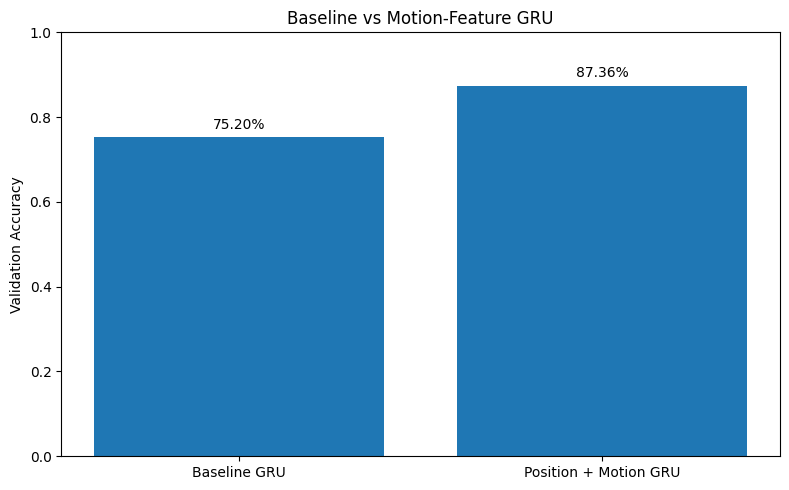

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Experiment"],
    comparison["Best Validation Accuracy"],
)

plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Motion-Feature GRU")
plt.ylim(0, 1)

for index, value in enumerate(
    comparison["Best Validation Accuracy"]
):
    plt.text(
        index,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
    )

plt.tight_layout()
plt.show()

#### 4. Save comparison results

In [ ]:
results_path = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "results"
    / "model_comparison.csv"
)

results_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

comparison.to_csv(
    results_path,
    index=False,
)

print("Saved:", results_path)

Saved: /content/drive/MyDrive/AirCommand/results/model_comparison.csv


## Re-train the model using all the training sequences and no validation (will be tested using test sequences)

In [ ]:
## combine the train and validation sequences
final_sequences = train_sequences + validation_sequences

final_labels = [
    sequence.class_id
    for sequence in final_sequences
]

print("Final sequences:", len(final_sequences))
print("Final labels:", len(final_labels))

Final sequences: 3117
Final labels: 3117


In [ ]:
## Add motion features
# Add first-order motion features to every development sequence.

final_sequences_with_motion = [
    add_motion_features(sequence.landmarks)
    for sequence in final_sequences
]

print("Number of sequences:", len(final_sequences_with_motion))
print("Example shape:", final_sequences_with_motion[0].shape)
print("Feature dimensions:", {
    sequence.shape[1]
    for sequence in final_sequences_with_motion
})

Number of sequences: 3117
Example shape: (38, 126)
Feature dimensions: {126}


In [ ]:
# Apply the finalized hybrid temporal preprocessing.

final_hybrid_sequences = [
    prepare_sequence(sequence, "hybrid")
    for sequence in final_sequences_with_motion
]

print("Number of sequences:", len(final_hybrid_sequences))
print(
    "Feature dimensions:",
    {sequence.shape[1] for sequence in final_hybrid_sequences}
)

sequence_lengths = [
    sequence.shape[0]
    for sequence in final_hybrid_sequences
]

print("Minimum sequence length:", min(sequence_lengths))
print("Maximum sequence length:", max(sequence_lengths))
print("Unique sequence lengths:", len(set(sequence_lengths)))

Number of sequences: 3117
Feature dimensions: {126}
Minimum sequence length: 8
Maximum sequence length: 256
Unique sequence lengths: 180


In [ ]:
## final dataset
from torch.utils.data import Dataset


class GestureDataset(Dataset):
    """PyTorch dataset for final gesture model training."""

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = np.asarray(labels) - 2

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.float32,
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )

        return sequence, label


final_dataset = GestureDataset(
    final_hybrid_sequences,
    final_labels,
)

print("Dataset size:", len(final_dataset))

sample_sequence, sample_label = final_dataset[0]

print("Sample sequence shape:", sample_sequence.shape)
print("Sample sequence dtype:", sample_sequence.dtype)
print("Sample label:", sample_label.item())

Dataset size: 3117
Sample sequence shape: torch.Size([38, 126])
Sample sequence dtype: torch.float32
Sample label: 12


In [ ]:
## handle variable sequence lengths
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader


def collate_sequences(batch):
    """Pad variable-length gesture sequences within each batch."""

    sequences, labels = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    lengths = torch.tensor(
        [sequence.shape[0] for sequence in sequences],
        dtype=torch.long,
    )

    labels = torch.stack(labels)

    return padded_sequences, lengths, labels


BATCH_SIZE = 32

final_loader = DataLoader(
    final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
)

print("Number of batches:", len(final_loader))

Number of batches: 98


In [ ]:
## test on one batch
batch_sequences, batch_lengths, batch_labels = next(iter(final_loader))

print("Batch sequences:", batch_sequences.shape)
print("Batch lengths:", batch_lengths.shape)
print("Batch labels:", batch_labels.shape)

print("First 5 sequence lengths:", batch_lengths[:5].tolist())
print("First 5 labels:", batch_labels[:5].tolist())

Batch sequences: torch.Size([32, 256, 126])
Batch lengths: torch.Size([32])
Batch labels: torch.Size([32])
First 5 sequence lengths: [50, 109, 256, 42, 182]
First 5 labels: [2, 5, 0, 3, 0]


In [ ]:
import torch
import torch.nn as nn


INPUT_SIZE = 126
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = 13
DROPOUT = 0.0


class GestureGRU(nn.Module):
    """GRU model for AirCommand gesture classification."""

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        dropout=0.0,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(packed)

        final_hidden = hidden[-1]

        return self.classifier(final_hidden)


model = GestureGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
)


print(model)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total parameters:", total_parameters)

GestureGRU(
  (gru): GRU(126, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=13, bias=True)
)
Total parameters: 99981


In [ ]:
import random
import numpy as np
import torch


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 15


# Device
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)


# Loss function
criterion = nn.CrossEntropyLoss()


# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


print("Device:", device)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Device: cuda
Learning rate: 0.001
Epochs: 15
Batch size: 32


In [ ]:
import time


training_start = time.time()

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for sequences, lengths, labels in final_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(
            sequences,
            lengths,
        )

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_accuracy:.4f}"
    )


training_time = (time.time() - training_start) / 60

print(f"\nFinal training time: {training_time:.2f} minutes")

Epoch 01/15 | Train Loss: 2.1731 | Train Acc: 0.2637
Epoch 02/15 | Train Loss: 1.7814 | Train Acc: 0.3670
Epoch 03/15 | Train Loss: 1.5327 | Train Acc: 0.4755
Epoch 04/15 | Train Loss: 1.2544 | Train Acc: 0.5810
Epoch 05/15 | Train Loss: 1.7026 | Train Acc: 0.4649
Epoch 06/15 | Train Loss: 1.3707 | Train Acc: 0.5662
Epoch 07/15 | Train Loss: 1.1687 | Train Acc: 0.6057
Epoch 08/15 | Train Loss: 0.9934 | Train Acc: 0.6724
Epoch 09/15 | Train Loss: 0.9134 | Train Acc: 0.6927
Epoch 10/15 | Train Loss: 0.8059 | Train Acc: 0.7295
Epoch 11/15 | Train Loss: 0.7450 | Train Acc: 0.7385
Epoch 12/15 | Train Loss: 0.7125 | Train Acc: 0.7533
Epoch 13/15 | Train Loss: 0.6646 | Train Acc: 0.7594
Epoch 14/15 | Train Loss: 0.6289 | Train Acc: 0.7818
Epoch 15/15 | Train Loss: 0.5786 | Train Acc: 0.7992

Final training time: 0.35 minutes


In [ ]:
from pathlib import Path
import torch


checkpoint_dir = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

checkpoint_path = (
    checkpoint_dir
    / "final_motion_gru.pt"
)


checkpoint = {
    "model_state_dict": model.state_dict(),

    "model_config": {
        "input_size": 126,
        "hidden_size": 128,
        "num_layers": 1,
        "num_classes": 13,
        "dropout": 0.0,
    },

    "preprocessing_config": {
        "features": "position + first_order_motion",
        "position_features": 63,
        "motion_features": 63,
        "sequence_strategy": "hybrid",
        "short_sequence_limit": 192,
        "long_sequence_limit": 256,
    },

    "training_config": {
        "learning_rate": 1e-3,
        "epochs": 15,
        "batch_size": 32,
        "seed": 42,
    },

    "class_mapping": {
        0: "B0A",
        1: "B0B",
        2: "G01",
        3: "G02",
        4: "G03",
        5: "G04",
        6: "G05",
        7: "G06",
        8: "G07",
        9: "G08",
        10: "G09",
        11: "G10",
        12: "G11",
    },

    "training_samples": len(final_dataset),
}


torch.save(
    checkpoint,
    checkpoint_path,
)

print("Final model saved to:", checkpoint_path)
print("Exists:", checkpoint_path.exists())
print(
    "File size:",
    f"{checkpoint_path.stat().st_size / (1024 ** 2):.2f} MB",
)

Final model saved to: /content/drive/MyDrive/AirCommand/checkpoints/final_motion_gru.pt
Exists: True
File size: 0.38 MB


## Key Findings
1. Model can get explicit information about direction through the explicit motion features
2. Comparison
* Overall Comparison
  baseline 63-feature GRU had:

  Accuracy: 74.25% at the final epoch
  Best validation accuracy: 75.20%
  Macro F1: 0.583

  The new position + motion model has:

  Accuracy: 87.36%
  Macro F1: 0.797
  Weighted F1: 0.870

* Class-wise performance
  baseline had:

  - G02  F1 = 0.054
  - G08  F1 = 0.192
  - G10  F1 = 0.453
  - G11  F1 = 0.270

  Now:

  - G02  F1 = 0.356
  - G08  F1 = 0.597
  - G10  F1 = 0.808
  - G11  F1 = 0.818

* G02 is still problematic, only 8/30 were identified.

3. Explicit first-order landmark displacement substantially improved temporal gesture recognition, increasing best validation accuracy from 75.20% to 87.36% and macro F1 from 0.583 to 0.797. The largest improvements occurred in previously difficult dynamic gestures, particularly G03, G07, G08, G10, and G11. Remaining errors are concentrated around temporally similar gestures, especially G01/G08 and G02/G08.




questions
1. why we added motion features cant gru process it by its own?
2. mediapipe study
3. gru code study